In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
df = pd.read_csv("heart_disease_prediction_classification.csv")
df.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  1

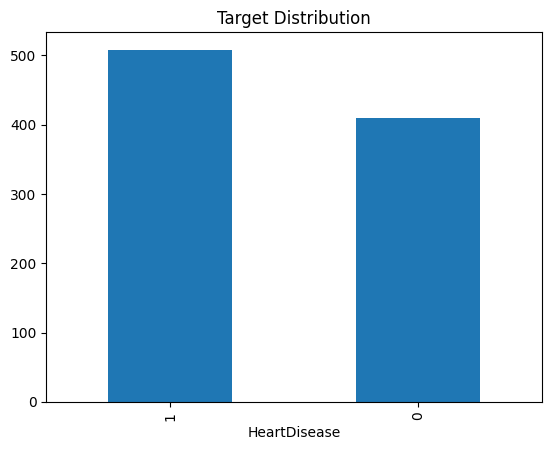

In [8]:
# =====================
# CELL 4 — BASIC EDA
# =====================

print(df.info())
print(df.describe())
print("Missing Values:\n", df.isnull().sum())

df.iloc[:, -1].value_counts().plot(kind='bar', title="Target Distribution")
plt.show()


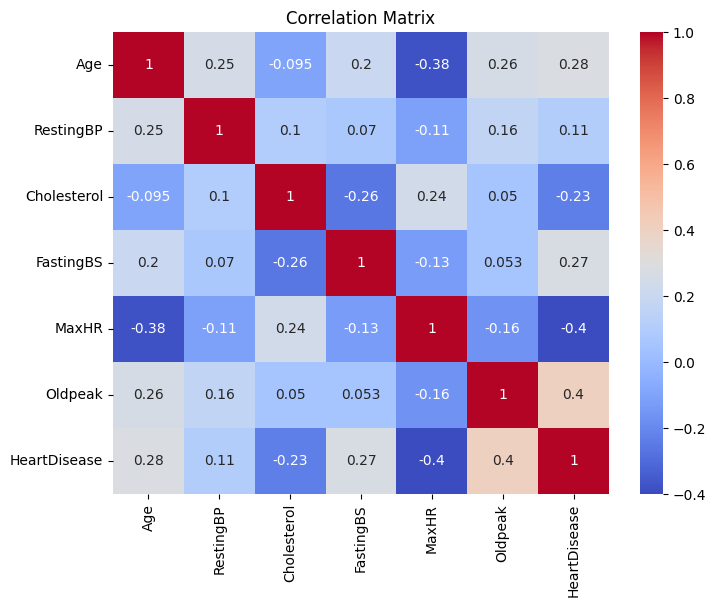

In [9]:
# ===============================
# CELL 5 — CORRELATION HEATMAP
# ===============================

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [10]:
# ==================================
# CELL 6 — HANDLE MISSING VALUES
# ==================================

mean_imputer = SimpleImputer(strategy='mean')
df['RestingBP'] = mean_imputer.fit_transform(df[['RestingBP']])

mode_imputer = SimpleImputer(strategy='most_frequent')
df['ExerciseAngina'] = mode_imputer.fit_transform(df[['ExerciseAngina']]).ravel()

print(df.isnull().sum())


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [11]:
# ==================================
# CELL 7 — FEATURE / TARGET SPLIT
# ==================================

X = df.iloc[:, :-1]
y = df.iloc[:, -1]


In [12]:
# ==========================
# CELL 8 — ENCODING
# ==========================

categorical_cols = ['Sex', 'ChestPainType', 'RestingECG',
                    'ExerciseAngina', 'ST_Slope']

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)


In [13]:
# ==========================
# CELL 9 — FEATURE SCALING
# ==========================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [14]:
# ==============================
# CELL 10 — TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [16]:
# ======================================
# CELL 11 — HANDLE IMBALANCE (SMOTE)
# ======================================

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", pd.Series(y_train_res).value_counts())


Before SMOTE:
 HeartDisease
1    401
0    333
Name: count, dtype: int64
After SMOTE:
 HeartDisease
0    401
1    401
Name: count, dtype: int64


In [17]:
# ==================================
# CELL 12 — LOGISTIC REGRESSION
# ==================================

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_res, y_train_res)

y_pred_log = log_model.predict(X_test)
print(classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

           0       0.80      0.88      0.84        77
           1       0.91      0.84      0.87       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



In [18]:
# ==================================
# CELL 13 — RANDOM FOREST
# ==================================

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_res, y_train_res)

y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.85      0.86      0.85        77
           1       0.90      0.89      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



In [19]:
# ==========================
# CELL 14 — SVM CLASSIFIER
# ==========================

svm_model = SVC()
svm_model.fit(X_train_res, y_train_res)

y_pred_svm = svm_model.predict(X_test)
print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

           0       0.84      0.87      0.85        77
           1       0.90      0.88      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



In [20]:
# ==========================
# CELL 15 — MODEL COMPARISON
# ==========================

results = pd.DataFrame({
    "Model": ["Logistic", "Random Forest", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted')
    ]
})

results


,Model,Accuracy,F1 Score
0,Logistic,0.858696,0.859441
1,Random Forest,0.875000,0.875110
2,SVM,0.875000,0.875306


In [21]:
# ==============================
# CELL 16 — CROSS VALIDATION
# ==============================

clf = RandomForestClassifier(random_state=42)
scores = cross_val_score(clf, X_scaled, y, cv=5)

print("Cross Validation Scores:", scores)
print("Mean CV Score:", scores.mean())


Cross Validation Scores: [0.85869565 0.82608696 0.83695652 0.81420765 0.7431694 ]
Mean CV Score: 0.8158232359230221


In [22]:
# ==========================
# CELL 17 — PCA
# ==========================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Before PCA Shape:", X_scaled.shape)
print("After PCA Shape:", X_pca.shape)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Before PCA Shape: (918, 15)
After PCA Shape: (918, 2)
Explained Variance Ratio: [0.22586656 0.11008684]


In [23]:
# ==========================================
# CELL 18 — BEFORE vs AFTER PCA PERFORMANCE
# ==========================================

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

model_pca = LogisticRegression(max_iter=1000)
model_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = model_pca.predict(X_test_pca)

print("Accuracy Before PCA:",
      accuracy_score(y_test, y_pred_log))

print("Accuracy After PCA:",
      accuracy_score(y_test_pca, y_pred_pca))


Accuracy Before PCA: 0.8586956521739131
Accuracy After PCA: 0.8043478260869565
